# <u>**Data Preprocessing and Training**</u>

## **1. Data Parsing and Extraction**

Before using this notebook, the training images and masks must be created and stored in an SqLite database file as described below

### **Program**: <span style="color:green;">**sqlite_dicom2.py**</span>

- **Input**: Data Directory containing patient info
- **Output**: an Sqlite3 database containing selected structures (currently by default sag images of the bladder midline and two layers to the left and right)

**Usage notes**: 
1. One file per patient, with all sequences in the zip file
2. Place all the zip files in a single directory
3. Launch sqlite_dicom2.py and select the directory containing the zip files
4. Enter a name for the sqlite database. It will be stored in the data directory.

___

## **2. Database Parsing and Modification**

After the creation of the database, it can be beneficial to parse through the images created and delete spurious ones. This can be done as follows:

### **Program**: <span style="color:yellow;">sqlite_viewer.py</span>

The database can be viewed and modified.
**Keys**: 
- m : show mask on/off
- d : delete current image and mask from database 
- arrow keys : move through the images
___

# Start of the program

In [1]:
# import the required modules
from sqlitedata import SqliteData
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from skimage.transform import rotate, AffineTransform, warp
from skimage.util import random_noise
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from scipy.spatial.distance import directed_hausdorff
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import os
import uuid


# Create subfolder if it doesn't exist
os.makedirs('images/bladder', exist_ok=True)


## **3. Load the Data**

- Use the sqlite database constructed during the parsing & extraction via the sqlite_dicom2 tool of the DICOM files
- Images are processed in their original size (88x512 pixels) without resizing or sliding-window approaches to preserve anatomical details.

In [2]:
# BLADDER
dbfile = 'images/bladder/images_bladder.sqlite'
db = SqliteData(dbfile)
# Get images, masks, patient IDs, and other available fields
try:
    images, masks, pat_ids, cbct_ids, stored_volumes, voxel_counts, voxel_spacings = db.get_images_and_masks('bladder')
except ValueError:
    # Fallback if fewer values are returned (older database without voxel_counts)
    images, masks, pat_ids, cbct_ids, stored_volumes, voxel_spacings = db.get_images_and_masks('bladder')
    voxel_counts = [0] * len(images)  # Placeholder for voxel_counts
    cbct_ids = [f'cbct_{i}' for i in range(len(images))] if len(cbct_ids) == 0 else cbct_ids  # Placeholder if cbct_ids unavailable
    stored_volumes = [0.0] * len(images) if len(stored_volumes) == 0 else stored_volumes  # Placeholder if stored_volumes unavailable
    voxel_spacings = [(0.908, 0.908, 1.988)] * len(images) if len(voxel_spacings) == 0 else voxel_spacings  # Default spacings

# Debug: Print lengths of returned data
print(f'Number of images: {len(images)}')
print(f'Number of masks: {len(masks)}')
print(f'Number of pat_ids: {len(pat_ids)}')
print(f'Number of cbct_ids: {len(cbct_ids)}')
print(f'Number of stored_volumes: {len(stored_volumes)}')
print(f'Number of voxel_counts: {len(voxel_counts)}')
print(f'Number of voxel_spacings: {len(voxel_spacings)}')
print(f'Sample cbct_ids: {cbct_ids[:5]}')

Number of images: 3533
Number of masks: 3533
Number of pat_ids: 3533
Number of cbct_ids: 3533
Number of stored_volumes: 3533
Number of voxel_counts: 3533
Number of voxel_spacings: 3533
Sample cbct_ids: ['1.2.752.243.1.1.20240426194524432.5260.40524', '1.2.752.243.1.1.20240426194524432.5260.40524', '1.2.752.243.1.1.20240426194524432.5260.40524', '1.2.752.243.1.1.20240426194524432.5260.40524', '1.2.752.243.1.1.20240426194524432.5260.40524']


In [3]:
# Create a pandas DataFrame with the patient IDs, images, masks, and other fields
df = pd.DataFrame({
    'pat_id': pat_ids,
    'cbct_id': cbct_ids,
    'images': images,
    'masks': masks,
    'stored_volume_ml': stored_volumes,
    'x_spacing': [vs[0] for vs in voxel_spacings],
    'y_spacing': [vs[1] for vs in voxel_spacings],
    'layer_spacing': [vs[2] for vs in voxel_spacings]
})

# Ensure pat_id and cbct_id are strings
df['pat_id'] = df['pat_id'].astype(str)
df['cbct_id'] = df['cbct_id'].astype(str)

# Debug: Check DataFrame columns and sample data
print('DataFrame columns:', df.columns.tolist())
print('Sample DataFrame:')
print(df[['pat_id', 'cbct_id', 'stored_volume_ml']].head())
df.info()


DataFrame columns: ['pat_id', 'cbct_id', 'images', 'masks', 'stored_volume_ml', 'x_spacing', 'y_spacing', 'layer_spacing']
Sample DataFrame:
  pat_id                                       cbct_id  stored_volume_ml
0   P001  1.2.752.243.1.1.20240426194524432.5260.40524        181.744829
1   P001  1.2.752.243.1.1.20240426194524432.5260.40524        181.744829
2   P001  1.2.752.243.1.1.20240426194524432.5260.40524        181.744829
3   P001  1.2.752.243.1.1.20240426194524432.5260.40524        181.744829
4   P001  1.2.752.243.1.1.20240426194524432.5260.40524        181.744829
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3533 entries, 0 to 3532
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pat_id            3533 non-null   object 
 1   cbct_id           3533 non-null   object 
 2   images            3533 non-null   object 
 3   masks             3533 non-null   object 
 4   stored_volume_ml  3533 non-n

In [4]:
# Print layer spacing, x and y spacing, and check for NaN
print(f'Layer spacing: {df["layer_spacing"].unique()}')
print(f'X spacing: {df["x_spacing"].unique()}')
print(f'Y spacing: {df["y_spacing"].unique()}')
nan_rows = df[df[['x_spacing', 'y_spacing', 'layer_spacing']].isna().any(axis=1)]
print(f'Rows with NaN spacing: {len(nan_rows)}/{len(df)}')
if len(nan_rows) > 0:
    print(nan_rows[['pat_id', 'cbct_id', 'x_spacing', 'y_spacing', 'layer_spacing']].head())


Layer spacing: [1.98849014]
X spacing: [0.90802036]
Y spacing: [0.90802036]
Rows with NaN spacing: 0/3533


In [5]:
# remove rows with empty masks, print number of removed rows
initial_length = len(df)
df = df[df['masks'].apply(lambda x: x is not None and len(x) > 0)]
removed_length = initial_length - len(df)
print(f'Removed {removed_length} rows with empty masks. Remaining rows: {len(df)}')

Removed 0 rows with empty masks. Remaining rows: 3533


### View Information about the Database Size and Distribution

Visualize a sample entry and analyze the distribution of bladder volumes to ensure balanced training/validation sets.

In [6]:
# Number of images in total
n_images = df.shape[0]
# Number of unique patients
n_patients = df['pat_id'].nunique()
# Number of images per patient
n_images_per_patient_df = df.groupby('pat_id').size()
max_images_per_patient = n_images_per_patient_df.max()
min_images_per_patient = n_images_per_patient_df.min()
print(f'Number of images: {n_images}')
print(f'Number of unique patients: {n_patients}')
print(f'Avg. number of images per patient: {n_images_per_patient_df.mean():.2f}')
print(f'Max. number of images per patient: {max_images_per_patient}, patient id: {n_images_per_patient_df.idxmax()}')
print(f'Min. number of images per patient: {min_images_per_patient}, patient id: {n_images_per_patient_df.idxmin()}')


Number of images: 3533
Number of unique patients: 129
Avg. number of images per patient: 27.39
Max. number of images per patient: 50, patient id: P044
Min. number of images per patient: 5, patient id: P132


Calculate the volume using an ellipsoid, for comparison to stored (measured) volume from mask volume

In [7]:
# Function to calculate ellipsoid volume
def vol_ellipsoid(x, y, z):
    # All dimensions in mm, volume in mm³, then convert to ml
    volume_ml = (4/3) * np.pi * x/2 * y/2 * z/2 / 1000
    return volume_ml

def calculate_bladder_volume(df, cbct_id):
    # Filter rows for the given CBCT scan
    cbct_slices = df[df['cbct_id'] == cbct_id]
    
    # Check if stored_volume_ml is consistent
    stored_volumes = cbct_slices['stored_volume_ml'].unique()
    if len(stored_volumes) > 1:
        print(f"Warning: Inconsistent stored_volume_ml for cbct_id {cbct_id}: {stored_volumes}")
    
    # Select the midline slice (largest mask area)
    max_area = 0
    midline_row = None
    for _, row in cbct_slices.iterrows():
        area = np.sum(row['masks']) * row['x_spacing'] * row['y_spacing']
        if area > max_area:
            max_area = area
            midline_row = row
    
    if midline_row is None:
        return 0, 0  # No valid mask
    
    # Get dimensions from the midline slice
    mask = midline_row['masks']
    non_zero_x = np.where(mask)[1]  # Left-right
    non_zero_y = np.where(mask)[0]  # Superior-inferior
    
    if len(non_zero_x) == 0 or len(non_zero_y) == 0:
        return 0, 0
    
    # Ellipsoid dimensions
    x_mm = (non_zero_x.max() - non_zero_x.min()) * midline_row['x_spacing']  # Left-right
    y_mm = x_mm  # Set y = x for symmetry
    z_mm = (non_zero_y.max() - non_zero_y.min()) * midline_row['y_spacing']  # Superior-inferior as axial
    
    # Calculate ellipsoid volume
    ell_volume_ml = vol_ellipsoid(x_mm, y_mm, z_mm) if x_mm > 0 and z_mm > 0 else 0
    
    return ell_volume_ml, max_area

# Apply to all CBCT scans
df['calculated_volume_ml'] = np.nan
for cbct_id in df['cbct_id'].unique():
    ell_volume, max_area = calculate_bladder_volume(df, cbct_id)
    # Assign the same ellipsoid volume to all slices of this CBCT
    df.loc[df['cbct_id'] == cbct_id, 'calculated_volume_ml'] = ell_volume  #* 0.51  # Apply correction factor 



In [8]:
# Close the database
db.close()


In [9]:
# compare stored_volume_ml and calculated_volume_ml
df['volume_diff'] = df['stored_volume_ml'] - df['calculated_volume_ml']
print(f'Median calculated volume: {df["calculated_volume_ml"].median():.2f} ml')
print(f'Median stored volume: {df["stored_volume_ml"].median():.2f} ml')
print(f'Mean calculated volume: {df["calculated_volume_ml"].mean():.2f} ml')
print(f'Mean stored volume: {df["stored_volume_ml"].mean():.2f} ml')
print(f'Mean volume difference (stored - calculated): {df["volume_diff"].mean():.2f} ml')
print(f'Standard deviation of volume difference: {df["volume_diff"].std():.2f} ml')
print(f'Max volume difference: {df["volume_diff"].max():.2f} ml')
print(f'Min volume difference: {df["volume_diff"].min():.2f} ml')

Median calculated volume: 162.74 ml
Median stored volume: 294.49 ml
Mean calculated volume: 177.45 ml
Mean stored volume: 321.37 ml
Mean volume difference (stored - calculated): 143.92 ml
Standard deviation of volume difference: 83.03 ml
Max volume difference: 544.65 ml
Min volume difference: 3.99 ml


## **4. Data Preprocessing**

1. **Filter Unusual Image Sizes**: Remove images with non-standard dimensions (e.g., (85, 512)) due to differing kV-CBCT protocols, retaining only the standard (88, 512) images.
2. **Normalization**: Normalize pixel intensities from the Hounsfield scale (0–8000) to [0, 1] by dividing by the maximum pixel value (8000) to ensure consistent input to the model.

In [10]:
# Check unique image sizes
df['image_shape'] = df['images'].apply(lambda x: x.shape)
image_shape_counts = df.groupby('image_shape').size()
print(f'Unique image sizes:')
for entry in image_shape_counts.index:
    print(f'{entry}: {image_shape_counts[entry]}')

# Remove all images with dimension not equal to (88,512) and corresponding masks
df = df[df['image_shape'] == (88, 512)]



Unique image sizes:
(76, 512): 5
(85, 512): 20
(88, 512): 3508


In [11]:
# Current pixel range for images
images_np = np.array(df['images'].tolist(), dtype=np.float32)
max_pixel = images_np.max()
min_pixel = images_np.min()
print(f'Pixel range for images: {min_pixel} - {max_pixel}')

# Normalize images to [0, 1]
df['images'] = df['images'].apply(lambda x: x / max_pixel)

# Verify normalization
images_np = np.array(df['images'].tolist(), dtype=np.float32)
print(f'Pixel range for images after normalization: {images_np.min()} - {images_np.max()}')
mask_np = np.array(df['masks'].tolist(), dtype=np.uint8)
print(f'Pixel range for masks: {mask_np.min()} - {mask_np.max()}')


Pixel range for images: 0.0 - 8000.0
Pixel range for images after normalization: 0.0 - 1.0
Pixel range for masks: 0 - 1


### Training and Validation Set Creation

- Split data into 80% training and 20% validation sets, ensuring patient-disjoint sets (no patient appears in both sets).
- Stratify by calculated volume to balance the sets.

In [12]:
# Split the dataset into training and validation sets, stratified by calculated volume
unique_pat_ids = df['pat_id'].unique()
patient_volumes = df.groupby('pat_id')['stored_volume_ml'].mean().reset_index()
patient_volumes['volume_bin'] = pd.qcut(patient_volumes['stored_volume_ml'], q=4, labels=False)
train_pat_ids, val_pat_ids = train_test_split(
    unique_pat_ids,
    test_size=0.2,
    random_state=42,
    stratify=patient_volumes['volume_bin']
)

train_df = df[df['pat_id'].isin(train_pat_ids)]
val_df = df[df['pat_id'].isin(val_pat_ids)]

# Print the number of images in the training and validation sets
print(f'Number of images in training set: {train_df.shape[0]}, from {train_df["pat_id"].nunique()} patients')
print(f'Number of images in validation set: {val_df.shape[0]}, from {val_df["pat_id"].nunique()} patients')

mask_np = np.array(df['masks'].tolist(), dtype=np.uint8)
print(f'Pixel range for masks: {mask_np.min()} - {mask_np.max()}')

# Statistical analysis of bladder volume distribution
from scipy.stats import ttest_ind
train_volumes = train_df['stored_volume_ml']
val_volumes = val_df['stored_volume_ml']
print(f'Training set bladder volume (mean ± std): {train_volumes.mean():.2f} ± {train_volumes.std():.2f} ml')
print(f'Validation set bladder volume (mean ± std): {val_volumes.mean():.2f} ± {val_volumes.std():.2f} ml')
t_stat, p_val = ttest_ind(train_volumes, val_volumes)
print(f'T-test p-value for bladder volume difference: {p_val:.3f}')


Number of images in training set: 2808, from 103 patients
Number of images in validation set: 700, from 26 patients
Pixel range for masks: 0 - 1
Training set bladder volume (mean ± std): 323.94 ± 163.58 ml
Validation set bladder volume (mean ± std): 317.43 ± 171.44 ml
T-test p-value for bladder volume difference: 0.351


In [13]:
# Print the patient IDs in the validation set for reference
print('Patient IDs in validation set:')
    
# make a list of patient IDs in the validation set for later use
val_pat_ids = val_df['pat_id'].unique().tolist()
print() 
for pat_id in val_pat_ids:
    print(f"'{pat_id}'", end=', ')
print()  # New line after the list

Patient IDs in validation set:

'P012', 'P019', 'P027', 'P031', 'P038', 'P045', 'P047', 'P050', 'P051', 'P055', 'P056', 'P060', 'P062', 'P065', 'P067', 'P068', 'P090', 'P107', 'P109', 'P112', 'P116', 'P118', 'P119', 'P124', 'P127', 'P132', 


### Create More Images by Augmentation

Increase the training images using rotation, horizontal flipping, noise addition, and distortion to improve model robustness. Ensure contiguous arrays to avoid negative strides.

In [14]:
# Quadruple the training images with augmentation
augmented_train_data = []

for index, row in train_df.iterrows():
    img = row['images']
    mask = row['masks']
    pat_id = row['pat_id']
    cbct_id = row['cbct_id']
    stored_volume_ml = row['stored_volume_ml']
    x_spacing = row['x_spacing']
    y_spacing = row['y_spacing']
    layer_spacing = row['layer_spacing']
    calculated_volume_ml = row['calculated_volume_ml']

    # 1. Original (ensure contiguous)
    original_img = np.copy(img)
    original_mask = np.copy(mask)

    # 2. Rotate by a random angle
    angle = np.random.randint(-10, 10)
    rotated_img = rotate(img, angle, preserve_range=True).copy()
    rotated_mask = rotate(mask, angle, preserve_range=True,order=0).copy()
    rotated_mask = (rotated_mask > 0.5).astype(np.uint8)  # Ensure binary mask

    # 3. Flip horizontally
    flipped_img = np.fliplr(img).copy()
    flipped_mask = np.fliplr(mask).copy()

    # 4. Add noise to the image
    noisy_img = random_noise(img, mode='gaussian', var=0.001).copy()
    noisy_mask = np.copy(mask)  # Masks typically don't need noise

    # 5. Distort the image
    rotation = np.random.uniform(-0.1, 0.1)
    shear = np.random.uniform(-0.1, 0.1)
    tform = AffineTransform(rotation=rotation, shear=shear)
    distorted_img = warp(img, tform.inverse, preserve_range=True).copy()
    distorted_mask = warp(mask, tform.inverse, preserve_range=True,order=0).copy()
    distored_mask = (distorted_mask > 0.5).astype(np.uint8)  # Ensure binary mask

    # 6. Random scaling (optional, can be added)
    scale_factor = np.random.uniform(0.9, 1.1)
    transformation = AffineTransform(scale=scale_factor).inverse
    scaled_img = warp(img, transformation, preserve_range=True).copy()
    scaled_mask = warp(mask, transformation, preserve_range=True,order=0).copy()
    scaled_mask = (scaled_mask > 0.5).astype(np.uint8)  # Ensure binary mask

    # Append all versions to the list
    for aug_img, aug_mask, method in zip(
        [original_img, rotated_img, flipped_img, noisy_img, distorted_img, scaled_img],
        [original_mask, rotated_mask, flipped_mask, noisy_mask, distorted_mask, scaled_mask],
        ['original', 'rotated', 'flipped', 'noisy', 'distorted', 'scaled']
    ):
        augmented_train_data.append({
            'pat_id': pat_id,
            'cbct_id': cbct_id,
            'augmentation_type': method,
            'images': aug_img,
            'masks': aug_mask,
            'stored_volume_ml': stored_volume_ml,
            'x_spacing': x_spacing,
            'y_spacing': y_spacing,
            'layer_spacing': layer_spacing,
            'calculated_volume_ml': calculated_volume_ml
        })

# Create augmented DataFrame
augmented_train_df = pd.DataFrame(augmented_train_data)
print(f'Training set size after augmentation: {len(augmented_train_df)}')


Training set size after augmentation: 16848


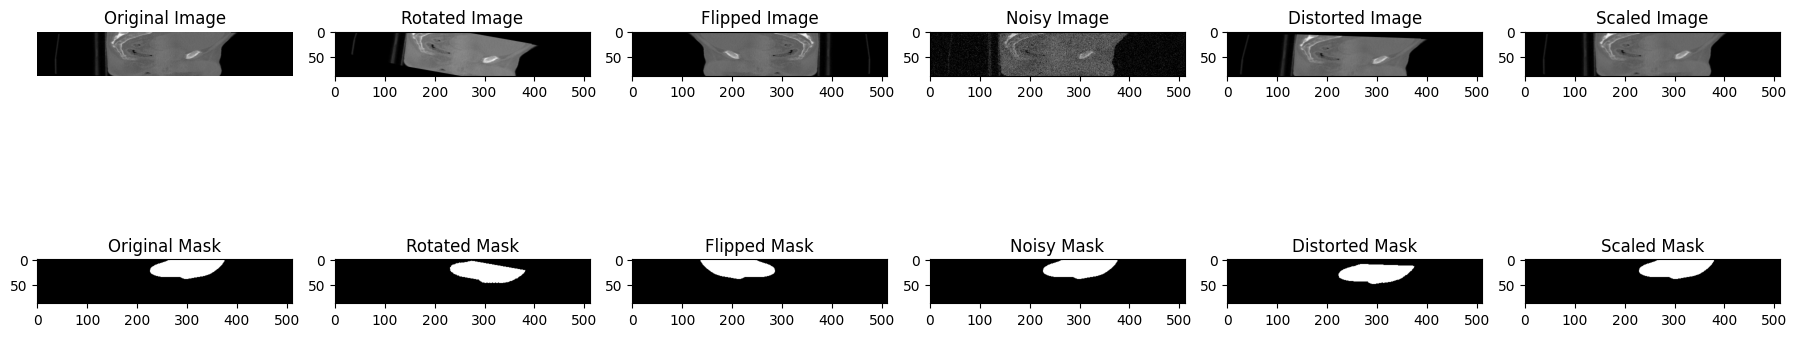

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
# from a random cbct_id, print a single image along with its augmented counterparts (1 of each rotated, flipped, noisy, distorted, and scaled) and the corresponding masks in a second row
import random
random_cbct_id = random.choice(augmented_train_df['cbct_id'].unique())
original_image = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'original')]['images'].values[0]
rotated_image = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'rotated')]['images'].values[0]
original_image = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'original')]['images'].values[0]
rotated_image = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'rotated')]['images'].values[0]
flipped_image = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'flipped')]['images'].values[0]
noisy_image = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'noisy')]['images'].values[0]
distorted_image = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'distorted')]['images'].values[0]
scaled_image = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'scaled')]['images'].values[0]
original_mask = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'original')]['masks'].values[0]
rotated_mask = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'rotated')]['masks'].values[0]
flipped_mask = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'flipped')]['masks'].values[0]
noisy_mask = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'noisy')]['masks'].values[0]
distorted_mask = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'distorted')]['masks'].values[0]
scaled_mask = augmented_train_df[(augmented_train_df['cbct_id'] == random_cbct_id) & (augmented_train_df['augmentation_type'] == 'scaled')]['masks'].values[0]
# Plot the original and augmented images with their masks
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes[0, 0].imshow(original_image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 1].imshow(rotated_image, cmap='gray')
axes[0, 1].set_title('Rotated Image')
axes[0, 2].imshow(flipped_image, cmap='gray')
axes[0, 2].set_title('Flipped Image')
axes[0, 3].imshow(noisy_image, cmap='gray')
axes[0, 3].set_title('Noisy Image')
axes[0, 4].imshow(distorted_image, cmap='gray')
axes[0, 4].set_title('Distorted Image')
axes[0, 5].imshow(scaled_image, cmap='gray')
axes[0, 5].set_title('Scaled Image')
axes[1, 0].imshow(original_mask, cmap='gray')
axes[1, 0].set_title('Original Mask')
axes[1, 1].imshow(rotated_mask, cmap='gray')
axes[1, 1].set_title('Rotated Mask')
axes[1, 2].imshow(flipped_mask, cmap='gray')
axes[1, 2].set_title('Flipped Mask')
axes[1, 3].imshow(noisy_mask, cmap='gray')
axes[1, 3].set_title('Noisy Mask')
axes[1, 4].imshow(distorted_mask, cmap='gray')
axes[1, 4].set_title('Distorted Mask')
axes[1, 5].imshow(scaled_mask, cmap='gray')
axes[1, 5].set_title('Scaled Mask')
for ax in axes.flat:
        ax.axis('off')
        plt.tight_layout()
        plt.show()


In [16]:
# additional check for zero masks
zero_mask_count = augmented_train_df['masks'].apply(lambda x: np.sum(x) == 0).sum()
print(f'Number of zero masks in augmented training set: {zero_mask_count}')
# and remove them
augmented_train_df = augmented_train_df[augmented_train_df['masks'].apply(lambda x: np.sum(x) > 0)]
print(f'Training set size after removing zero masks: {len(augmented_train_df)}')

Number of zero masks in augmented training set: 4
Training set size after removing zero masks: 16844


In [17]:
# Metric functions
def dice_coefficient(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def precision_recall(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    true_positive = (pred * target).sum()
    precision = true_positive / (pred.sum() + 1e-6)
    recall = true_positive / (target.sum() + 1e-6)
    return precision.item(), recall.item()

def hausdorff_distance(pred, target, threshold=0.5):
    pred = (pred > threshold).cpu().numpy().squeeze()
    target = target.cpu().numpy().squeeze()
    pred_coords = np.array(np.where(pred)).T
    target_coords = np.array(np.where(target)).T
    if len(pred_coords) == 0 or len(target_coords) == 0:
        return np.nan
    return max(directed_hausdorff(pred_coords, target_coords)[0], 
               directed_hausdorff(target_coords, pred_coords)[0])

## **5. Model Training and Evaluation**

- Use the optimized U-Net model (with batch normalization) for 2D segmentation of midline sagittal slices, preserving the original architecture as described in the paper.
- Perform 5-fold cross-validation to assess model robustness and monitor training/validation loss.
- Evaluate using Dice coefficient, Hausdorff distance, precision, and recall to capture boundary accuracy.
- Support loading a pretrained model or training from scratch.
- Save checkpoints after each epoch to avoid re-running training.

In [18]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)
        self.bottleneck = self.conv_block(512, 1024)
        self.upconv4 = self.upconv(1024, 512)
        self.decoder4 = self.conv_block(1024, 512)
        self.upconv3 = self.upconv(512, 256)
        self.decoder3 = self.conv_block(512, 256)
        self.upconv2 = self.upconv(256, 128)
        self.decoder2 = self.conv_block(256, 128)
        self.upconv1 = self.upconv(128, 64)
        self.decoder1 = self.conv_block(128, 64)
        self.conv_last = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def pad_and_concat(self, dec, enc):
      # Dynamic padding to match encoder dimensions
      enc_h, enc_w = enc.shape[2:]
      dec_h, dec_w = dec.shape[2:]
      # Calculate padding
      padding_bottom = enc_h - dec_h
      padding_right = enc_w - dec_w
      # Only pad if needed
      if padding_bottom > 0 or padding_right > 0:
          dec = F.pad(dec, (0, padding_right, 0, padding_bottom))
      elif padding_bottom < 0 or padding_right < 0:
          enc = F.pad(enc, (0, -padding_right, 0, -padding_bottom))
      return torch.cat([dec, enc], dim=1)

    def forward(self, x):
        enc1 = self.encoder1(x)  # (batch, 64, 88, 512)
        enc2 = self.encoder2(F.max_pool2d(enc1, 2))  # (batch, 128, 44, 256)
        enc3 = self.encoder3(F.max_pool2d(enc2, 2))  # (batch, 256, 22, 128)
        enc4 = self.encoder4(F.max_pool2d(enc3, 2))  # (batch, 512, 11, 64)
        bottleneck = self.bottleneck(F.max_pool2d(enc4, 2))  # (batch, 1024, 5, 32)
        dec4 = self.upconv4(bottleneck)  # (batch, 512, 10, 64)
        dec4 = self.pad_and_concat(dec4, enc4)  # (batch, 1024, 11, 64)
        dec4 = self.decoder4(dec4)  # (batch, 512, 11, 64)
        dec3 = self.upconv3(dec4)  # (batch, 256, 22, 128)
        dec3 = self.pad_and_concat(dec3, enc3)  # (batch, 512, 22, 128)
        dec3 = self.decoder3(dec3)  # (batch, 256, 22, 128)
        dec2 = self.upconv2(dec3)  # (batch, 128, 44, 256)
        dec2 = self.pad_and_concat(dec2, enc2)  # (batch, 256, 44, 256)
        dec2 = self.decoder2(dec2)  # (batch, 128, 44, 256)
        dec1 = self.upconv1(dec2)  # (batch, 64, 88, 512)
        dec1 = self.pad_and_concat(dec1, enc1)  # (batch, 128, 88, 512)
        dec1 = self.decoder1(dec1)  # (batch, 64, 88, 512)
        return self.conv_last(dec1)  # (batch, 1, 88, 512)

In [19]:
# Custom Dataset class with negative strides fix
class ImageDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images.iloc[idx]
        mask = self.masks.iloc[idx]
        # Ensure contiguous arrays
        if not image.flags['C_CONTIGUOUS']:
            image = np.ascontiguousarray(image)
        if not mask.flags['C_CONTIGUOUS']:
            mask = np.ascontiguousarray(mask)
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        return image, mask

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler
from sklearn.model_selection import KFold
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle

def train_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3, device=None, patience=10):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    scaler = GradScaler('cuda') 
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * images.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                with autocast(device_type='cuda'):
                    outputs = model(images)
                val_loss += loss.item() * images.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    
    return model, train_losses, val_losses



In [21]:
# Function to perform k-fold cross-validation
def cross_validate_model(train_df, num_folds=5, num_epochs=50, lr=1e-3, start_fold=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    unique_pat_ids = train_df['pat_id'].apply(lambda x: x.split('_')[0]).unique()
    fold_results = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(unique_pat_ids)):
        if fold < start_fold - 1:
            continue
        print(f'\nFold {fold+1}/{num_folds}')
        
        # Split patients
        train_pats = unique_pat_ids[train_idx]
        val_pats = unique_pat_ids[val_idx]
        fold_train_df = train_df[train_df['pat_id'].apply(lambda x: x.split('_')[0]).isin(train_pats)]
        fold_val_df = train_df[train_df['pat_id'].apply(lambda x: x.split('_')[0]).isin(val_pats)]
        
        # Filter out empty masks
        fold_train_df = fold_train_df[fold_train_df['masks'].apply(lambda x: np.any(x))]
        fold_val_df = fold_val_df[fold_val_df['masks'].apply(lambda x: np.any(x))]
        print(f"Fold {fold+1}: Train samples: {len(fold_train_df)}, Val samples: {len(fold_val_df)}")
        
        # Create datasets and loaders
        train_dataset = ImageDataset(fold_train_df['images'], fold_train_df['masks'])
        val_dataset = ImageDataset(fold_val_df['images'], fold_val_df['masks'])
        train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, pin_memory=True, num_workers=4)
        val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, pin_memory=True, num_workers=4)
        
        # Initialize model
        model = UNet(in_channels=1, out_channels=1)
        model = torch.compile(model)
        
        # Train model
        model, train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs, lr, device)
        
        # Evaluate on validation fold
        model.eval()
        dice_scores = []
        hausdorff_scores = []
        precisions = []
        recalls = []
        empty_pred_count = 0
        sample_indices = []
        pat_ids = fold_val_df['pat_id'].values
        with torch.no_grad():
            for batch_idx, (images, masks) in enumerate(val_loader):
                images, masks = images.to(device), masks.to(device)
                outputs = torch.sigmoid(model(images))
                for i in range(images.size(0)):
                    global_idx = batch_idx * 8 + i  # Fix: Use batch_size=8
                    if global_idx >= len(val_dataset):
                        print(f"Warning: global_idx {global_idx} exceeds dataset size {len(val_dataset)}. Skipping.")
                        continue
                    if not torch.any(masks[i] > 0):
                        print(f"Skipping empty ground-truth mask for sample {global_idx}, pat_id: {pat_ids[global_idx]}")
                        continue
                    dice = dice_coefficient(outputs[i], masks[i]).item()
                    precision, recall = precision_recall(outputs[i], masks[i])
                    if not torch.any(outputs[i] > 0.5):
                        print(f"Empty prediction for sample {global_idx}, pat_id: {pat_ids[global_idx]}")
                        empty_pred_count += 1
                        hausdorff = np.nan  # Fix: Use np.nan for empty predictions
                    else:
                        hausdorff = hausdorff_distance(outputs[i], masks[i])
                    dice_scores.append(dice)
                    precisions.append(precision)
                    recalls.append(recall)
                    hausdorff_scores.append(hausdorff)
                    sample_indices.append(global_idx)
        
        # Visualize worst-case prediction
        if dice_scores and sample_indices:
            worst_idx = np.argmin(dice_scores)
            worst_global_idx = sample_indices[worst_idx]
            if worst_global_idx < len(val_dataset):  # Safety check
                worst_image = val_dataset[worst_global_idx][0].cpu().numpy().squeeze()
                worst_mask = val_dataset[worst_global_idx][1].cpu().numpy().squeeze()
                worst_pred = (torch.sigmoid(model(val_dataset[worst_global_idx][0].to(device)[None])) > 0.5).cpu().numpy().squeeze()
                plt.figure(figsize=(15, 5))
                plt.subplot(1, 3, 1)
                plt.imshow(worst_image, cmap='gray')
                plt.title('Image')
                plt.subplot(1, 3, 2)
                plt.imshow(worst_mask, cmap='gray')
                plt.title('Ground Truth')
                plt.subplot(1, 3, 3)
                plt.imshow(worst_pred, cmap='gray')
                plt.title(f'Prediction (Dice: {dice_scores[worst_idx]:.4f})')
                plt.savefig(f'images/bladder/worst_case_fold_{fold+1}.png')
                plt.close()
            else:
                print(f"Warning: worst_global_idx {worst_global_idx} exceeds dataset size {len(val_dataset)}. Skipping visualization.")
        
        # Store fold metrics
        fold_results.append({
            'fold': fold + 1,
            'mean_dice': np.mean(dice_scores) if dice_scores else 0.0,
            'std_dice': np.std(dice_scores) if dice_scores else 0.0,
            'mean_precision': np.mean(precisions) if precisions else 0.0,
            'mean_recall': np.mean(recalls) if recalls else 0.0,
            'mean_hausdorff': np.nanmean(hausdorff_scores) if hausdorff_scores else np.nan,
            'empty_pred_count': empty_pred_count,
            'train_losses': train_losses,
            'val_losses': val_losses
        })
        print(f"Fold {fold+1} Metrics: Dice: {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}, "
              f"Precision: {np.mean(precisions):.4f}, Recall: {np.mean(recalls):.4f}, "
              f"Hausdorff: {np.nanmean(hausdorff_scores):.4f}, Empty Predictions: {empty_pred_count}")
        
        # Save fold model
        torch.save(model.state_dict(), f'model_bladder_fold_{fold+1}.pth')
    
    # Aggregate and print results
    mean_dice = np.mean([r['mean_dice'] for r in fold_results])
    mean_precision = np.mean([r['mean_precision'] for r in fold_results])
    mean_recall = np.mean([r['mean_recall'] for r in fold_results])
    mean_hausdorff = np.nanmean([r['mean_hausdorff'] for r in fold_results])
    print(f'\nCross-Validation Results:')
    print(f'Mean Dice: {mean_dice:.4f}')
    print(f'Mean Precision: {mean_precision:.4f}')
    print(f'Mean Recall: {mean_recall:.4f}')
    print(f'Mean Hausdorff Distance: {mean_hausdorff:.4f}')
    
    # Save fold results to a file
    with open('models/fold_results_bladder.pkl', 'wb') as f:
        pickle.dump(fold_results, f)
    
    return fold_results

In [22]:
# function to train final model
def train_final_model(train_df, val_df, num_epochs=50, lr=1e-3, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_dataset = ImageDataset(train_df['images'], train_df['masks'])
    val_dataset = ImageDataset(val_df['images'], val_df['masks'])
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, pin_memory=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, pin_memory=True, num_workers=4)
    model = UNet(in_channels=1, out_channels=1)
    model, _, _ = train_model(model, train_loader, val_loader, num_epochs, lr, device)
    torch.save(model.state_dict(), 'models/model_bladder.pth')
    return model

In [23]:
import torch
# check if cuda is available
if torch.cuda.is_available():
    #get gpu name
    gpu_name = torch.cuda.get_device_name(0)
    print(f"CUDA is available. Using {gpu_name} for training.")
else:
    print("CUDA is not available. Using CPU for training.")

CUDA is available. Using NVIDIA GeForce RTX 5080 Laptop GPU for training.


In [24]:
# Cross validate model and train final model

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Flag to control retraining
RUN_CROSS_VALIDATION = False  # Set to True to force retraining

if RUN_CROSS_VALIDATION:
    # Run cross-validation and train final model
    fold_results = cross_validate_model(augmented_train_df, num_folds=5, num_epochs=50, start_fold=1)
    final_model = train_final_model(augmented_train_df, val_df, num_epochs=50, lr=1e-3, device=device)
else:
    # Check if final model exists
    if os.path.exists('models/model_bladder.pth'):
        # Load the final model
        final_model = UNet(in_channels=1, out_channels=1)
        final_model.load_state_dict(torch.load('models/model_bladder.pth'))
        final_model = final_model.to(device)
        print("Loaded saved final model.")
        
        # Check if fold results exist
        if os.path.exists('models/fold_results_bladder.pkl'):
            with open('models/fold_results_bladder.pkl', 'rb') as f:
                fold_results = pickle.load(f)
            print("Loaded saved fold results.")
        else:
            fold_results = None
            print("No fold results found.")
    else:
        # Train final model if no saved model exists
        print("No saved model found. Training final model.")
        final_model = train_final_model(augmented_train_df, val_df, num_epochs=50, lr=1e-3, device=device)
        fold_results = None

Loaded saved final model.
Loaded saved fold results.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load fold results
with open('models/fold_results_bladder.pkl', 'rb') as f:
    fold_results = pickle.load(f)

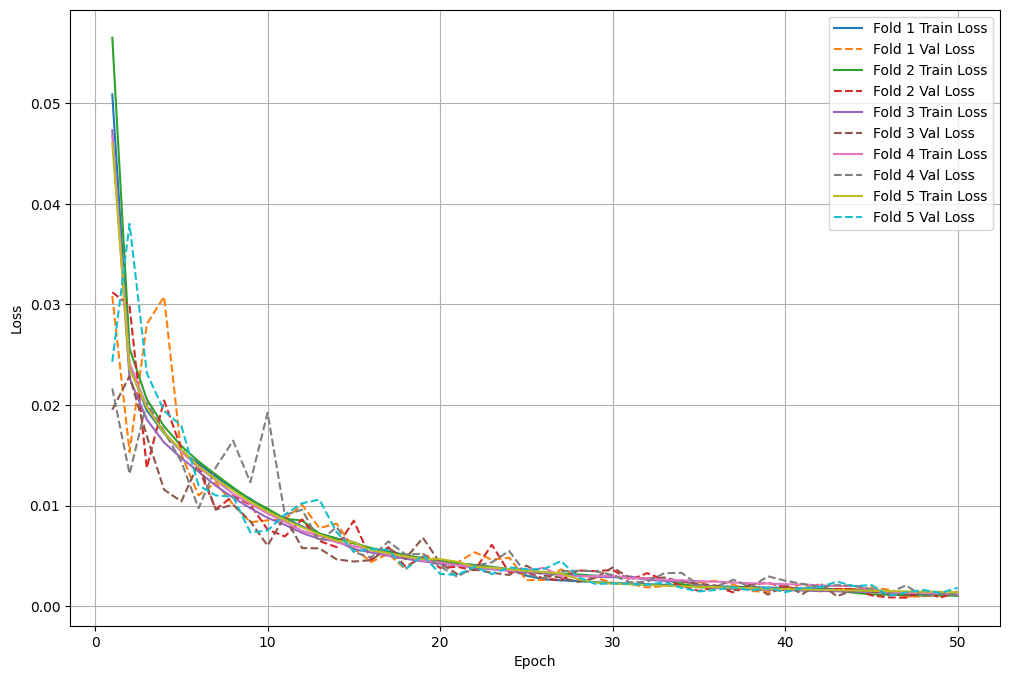

In [35]:
# Plot Training and Validation Loss Curves
plt.figure(figsize=(12, 8))
for fold_result in fold_results:
    fold = fold_result['fold']
    train_losses = fold_result['train_losses']
    val_losses = fold_result['val_losses']
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label=f'Fold {fold} Train Loss')
    plt.plot(epochs, val_losses, '--', label=f'Fold {fold} Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
# plt.title('Bladder: Training and Validation Loss Across Folds')
plt.legend()
plt.grid(True)

# Save to subfolder
plt.savefig('images/bladder/loss_curves.png', bbox_inches='tight')
# Display inline
plt.show()

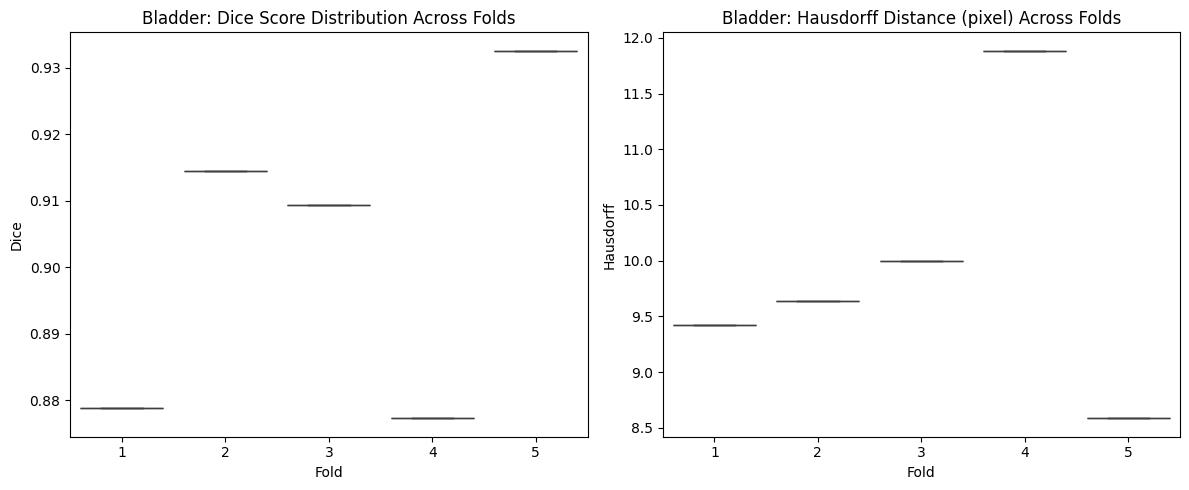

In [27]:
# Create DataFrame for metrics
metrics_df = pd.DataFrame([
    {'Fold': r['fold'], 'Dice': r['mean_dice'], 'Hausdorff': r['mean_hausdorff'], 'Empty Predictions': r['empty_pred_count']}
    for r in fold_results
])

# Plot metric distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Fold', y='Dice', data=metrics_df)
plt.title('Bladder: Dice Score Distribution Across Folds')
plt.subplot(1, 2, 2)
sns.boxplot(x='Fold', y='Hausdorff', data=metrics_df)
plt.title('Bladder: Hausdorff Distance (pixel) Across Folds')
plt.tight_layout()

# Save to subfolder
plt.savefig('images/bladder/metric_distributions.png', bbox_inches='tight')
# Display inline
plt.show()

Validation Set Metrics: Dice: 0.9149 ± 0.0852, Precision: 0.8974, Recall: 0.9454, Hausdorff: 9.1419 ± 9.0216, Empty Predictions: 0


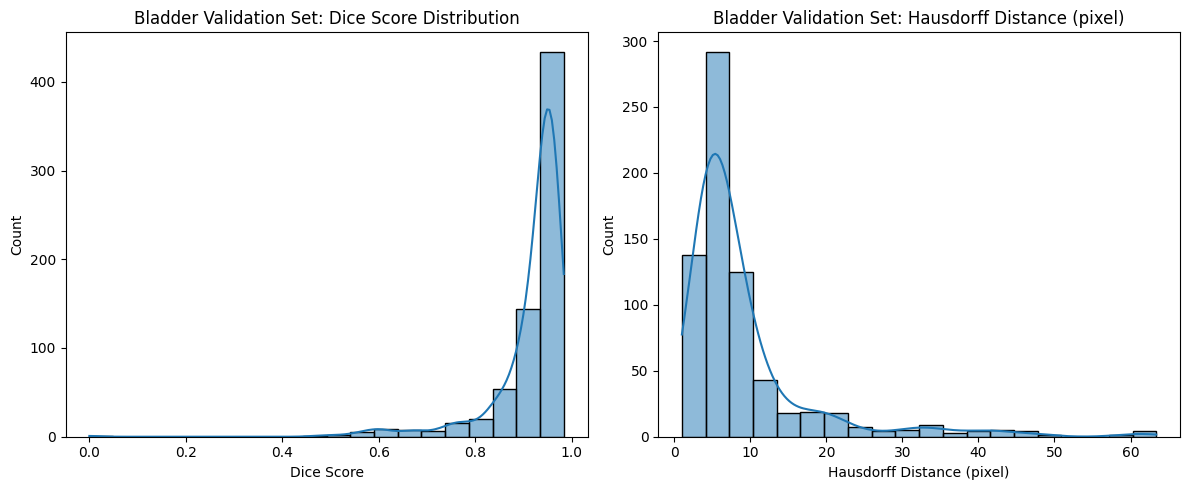

In [28]:
# Evaluate Validation Set
val_df = val_df.reset_index(drop=True)
val_dataset = ImageDataset(val_df['images'], val_df['masks'])
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, pin_memory=True)
dice_scores_val = []
precisions_val = []
recalls_val = []
hausdorff_scores_val = []
empty_pred_count_val = 0
pat_ids_val = val_df['pat_id'].values
val_masks_pred_binary = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.eval()
with torch.no_grad():
    for i, (images, masks) in enumerate(val_loader):
        images, masks = images.to(device), masks.to(device)
        outputs = torch.sigmoid(final_model(images))
        pred_binary = (outputs > 0.5).float()
        val_masks_pred_binary.append(pred_binary.cpu().numpy())
        dice = dice_coefficient(outputs, masks).item()
        precision, recall = precision_recall(outputs, masks)
        hausdorff = hausdorff_distance(outputs, masks) if torch.any(outputs > 0.5) else np.nan
        if not torch.any(outputs > 0.5):
            print(f"Empty prediction for sample {i}, pat_id: {pat_ids_val[i]}")
            empty_pred_count_val += 1
        dice_scores_val.append(dice)
        precisions_val.append(precision)
        recalls_val.append(recall)
        hausdorff_scores_val.append(hausdorff)

val_masks_pred_binary = np.array(val_masks_pred_binary)
print(f"Validation Set Metrics: Dice: {np.mean(dice_scores_val):.4f} ± {np.std(dice_scores_val):.4f}, "
      f"Precision: {np.mean(precisions_val):.4f}, Recall: {np.mean(recalls_val):.4f}, "
      f"Hausdorff: {np.nanmean(hausdorff_scores_val):.4f} ± {np.nanstd(hausdorff_scores_val):.4f}, "
      f"Empty Predictions: {empty_pred_count_val}")

# Save validation metrics
val_results_summary = {
    'mean_dice': np.mean(dice_scores_val),
    'std_dice': np.std(dice_scores_val),
    'mean_precision': np.mean(precisions_val),
    'mean_recall': np.mean(recalls_val),
    'mean_hausdorff': np.nanmean(hausdorff_scores_val),
    'std_hausdorff': np.nanstd(hausdorff_scores_val),
    'empty_pred_count': empty_pred_count_val
}
with open('models/val_results_bladder.pkl', 'wb') as f:
    pickle.dump(val_results_summary, f)

# Plot validation set metric distributions
val_results = pd.DataFrame({'pat_id': pat_ids_val, 'dice': dice_scores_val, 'hausdorff': hausdorff_scores_val})
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(val_results['dice'], bins=20, kde=True)
plt.title('Bladder Validation Set: Dice Score Distribution')
plt.xlabel('Dice Score')
plt.subplot(1, 2, 2)
sns.histplot(val_results['hausdorff'].dropna(), bins=20, kde=True)
plt.title('Bladder Validation Set: Hausdorff Distance (pixel)')
plt.xlabel('Hausdorff Distance (pixel)')
plt.tight_layout()

# Save to subfolder
plt.savefig('images/bladder/val_metrics_distribution.png', bbox_inches='tight')
# Display inline
plt.show()

In [29]:
# print the metrics for the final model
print(f"Final Model Validation Metrics: Dice: {val_results_summary['mean_dice']:.4f} ± {val_results_summary['std_dice']:.4f}, "
      f"Precision: {val_results_summary['mean_precision']:.4f}, Recall: {val_results_summary['mean_recall']:.4f}, "
      f"Hausdorff: {val_results_summary['mean_hausdorff']:.4f}, Empty Predictions: {val_results_summary['empty_pred_count']}")

Final Model Validation Metrics: Dice: 0.9149 ± 0.0852, Precision: 0.8974, Recall: 0.9454, Hausdorff: 9.1419, Empty Predictions: 0


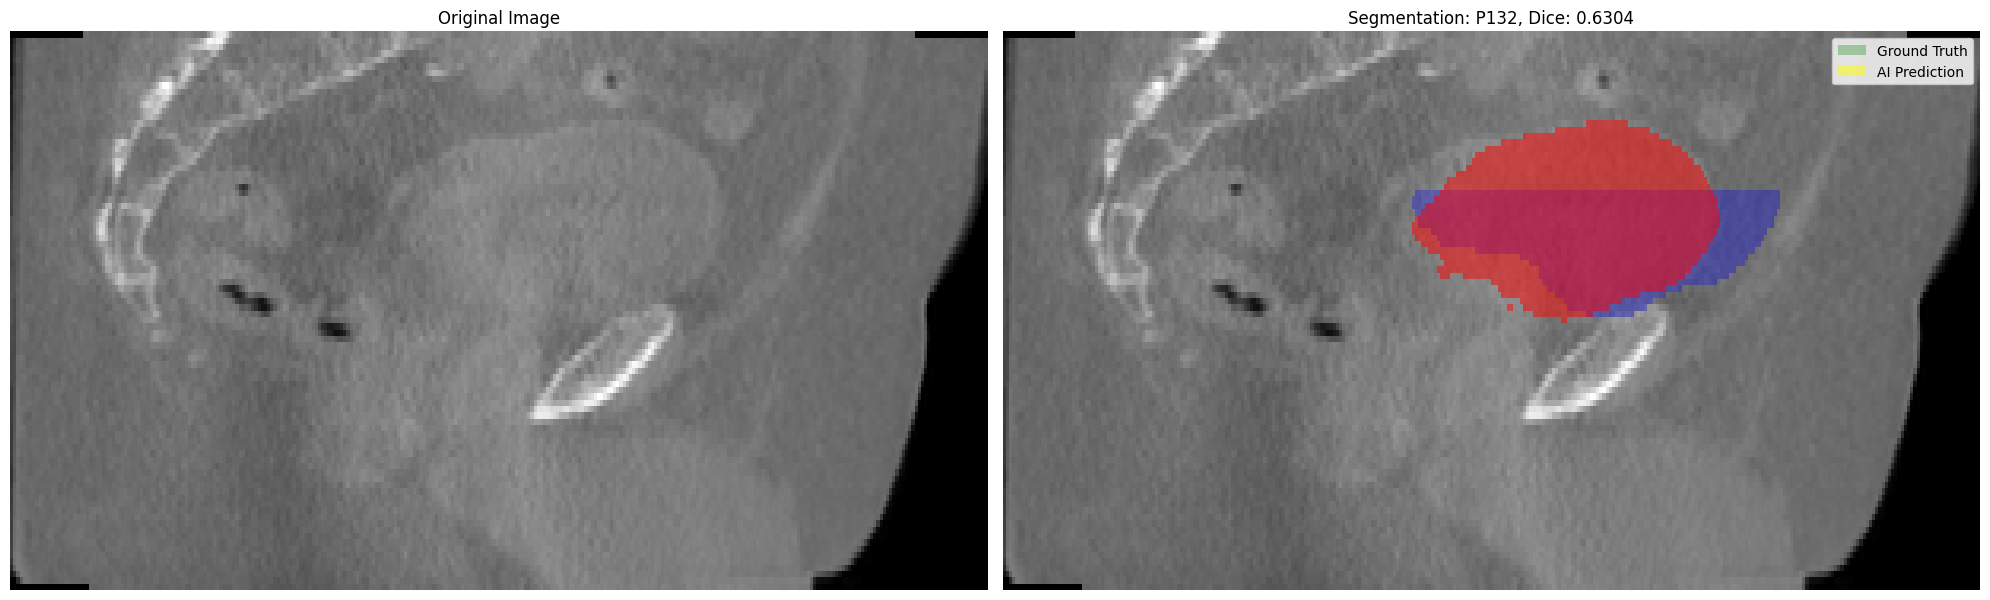

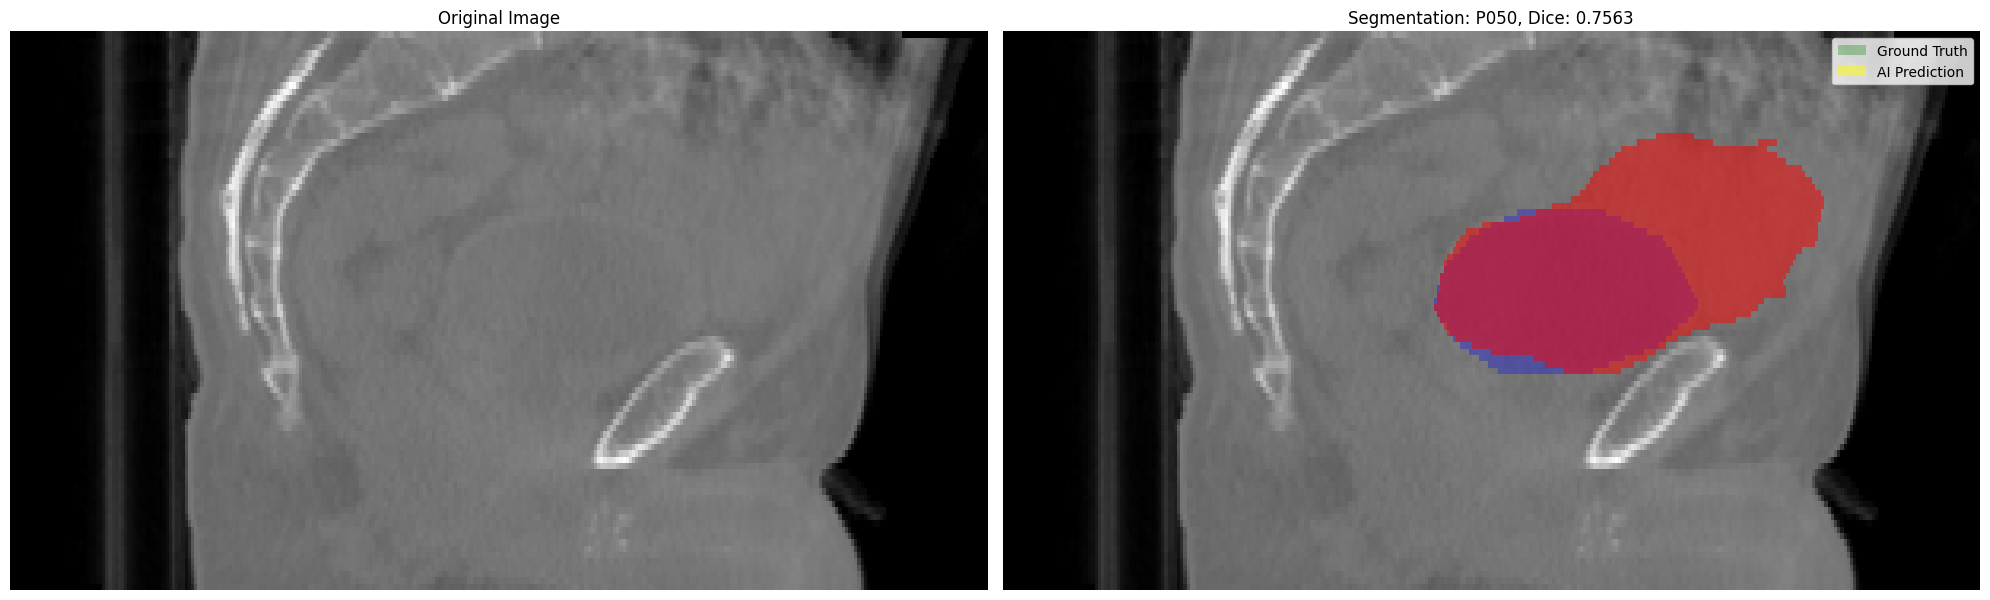

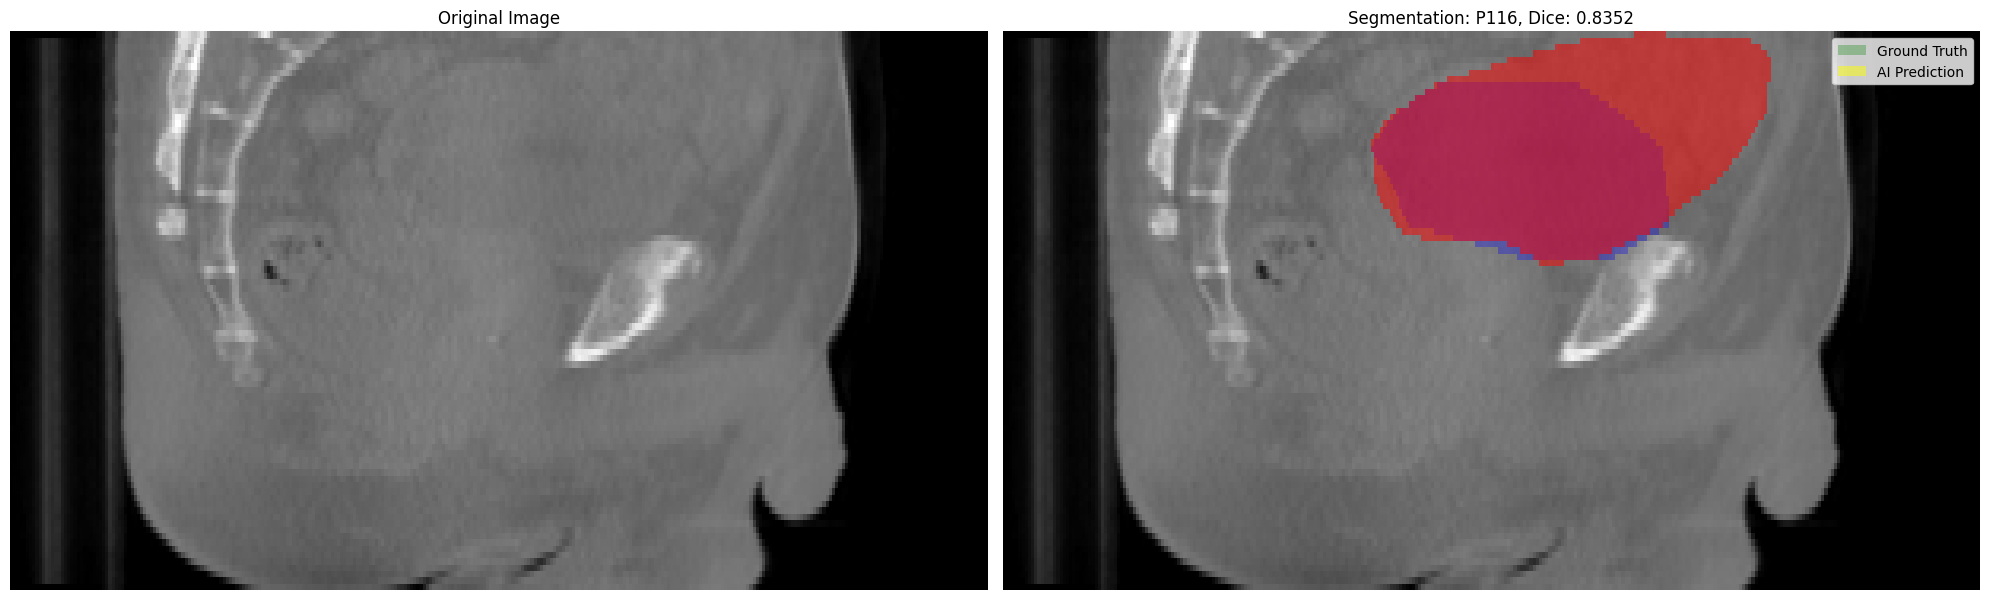

In [30]:
from matplotlib.colors import ListedColormap

# Visualize worst-case segmentations
worst_pats = val_results.groupby('pat_id')['dice'].mean().nsmallest(3).index
for pat_id in worst_pats:
    pat_idx = val_df[val_df['pat_id'] == pat_id].index[0]
    pat_df = val_df.iloc[pat_idx]
    
    # Get image and mask dimensions
    img = pat_df['images']
    height, width = img.shape
    
    # Calculate cropping indices (remove 1/5 from each side, i.e., 20% of width)
    crop_width = int(width * 0.2)  # 1/5 of width
    crop_slice = slice(crop_width, width - crop_width)
    
    # Crop images and masks
    cropped_img = img[:, crop_slice]
    cropped_ground_truth = pat_df['masks'][:, crop_slice]
    cropped_pred_mask = val_masks_pred_binary[pat_idx].squeeze()[:, crop_slice]
    
    # Create 1x2 subplot grid
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Plot original cropped image
    sns.heatmap(cropped_img, ax=axes[0], cmap='gray', cbar=False)
    axes[0].set_title('Original Image')
    axes[0].set_aspect(2)
    axes[0].axis('off')
    
    # Plot overlaid masks
    sns.heatmap(cropped_img, ax=axes[1], cmap='gray', cbar=False)
    
    # Ground truth mask (blue, translucent)
    cmask_zeros = cropped_ground_truth == 0
    alpha = np.ones_like(cropped_ground_truth, dtype=float) * 0.3
    alpha[cmask_zeros] = 0.0
    blue_cmap = ListedColormap(['none', 'blue'])
    sns.heatmap(cropped_ground_truth, ax=axes[1], cmap=blue_cmap, alpha=alpha, cbar=False)
    
    # AI-generated mask (red, translucent)
    vmask_zeros = cropped_pred_mask == 0
    alpha = np.ones_like(cropped_pred_mask, dtype=float) * 0.5
    alpha[vmask_zeros] = 0.0
    red_cmap = ListedColormap(['none', 'red'])
    sns.heatmap(cropped_pred_mask, ax=axes[1], cmap=red_cmap, alpha=alpha, cbar=False)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.3, label='Ground Truth'),
        Patch(facecolor='yellow', alpha=0.5, label='AI Prediction')
    ]
    axes[1].legend(handles=legend_elements, loc='upper right')
    
    axes[1].set_aspect(2)
    axes[1].axis('off')
    axes[1].set_title(f'Segmentation: {pat_id}, Dice: {val_results[val_results["pat_id"] == pat_id]["dice"].mean():.4f}')
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Save to subfolder
    plt.savefig(f'images/bladder/worst_val_case_{pat_id}.png', bbox_inches='tight')
    plt.show()
    plt.close()

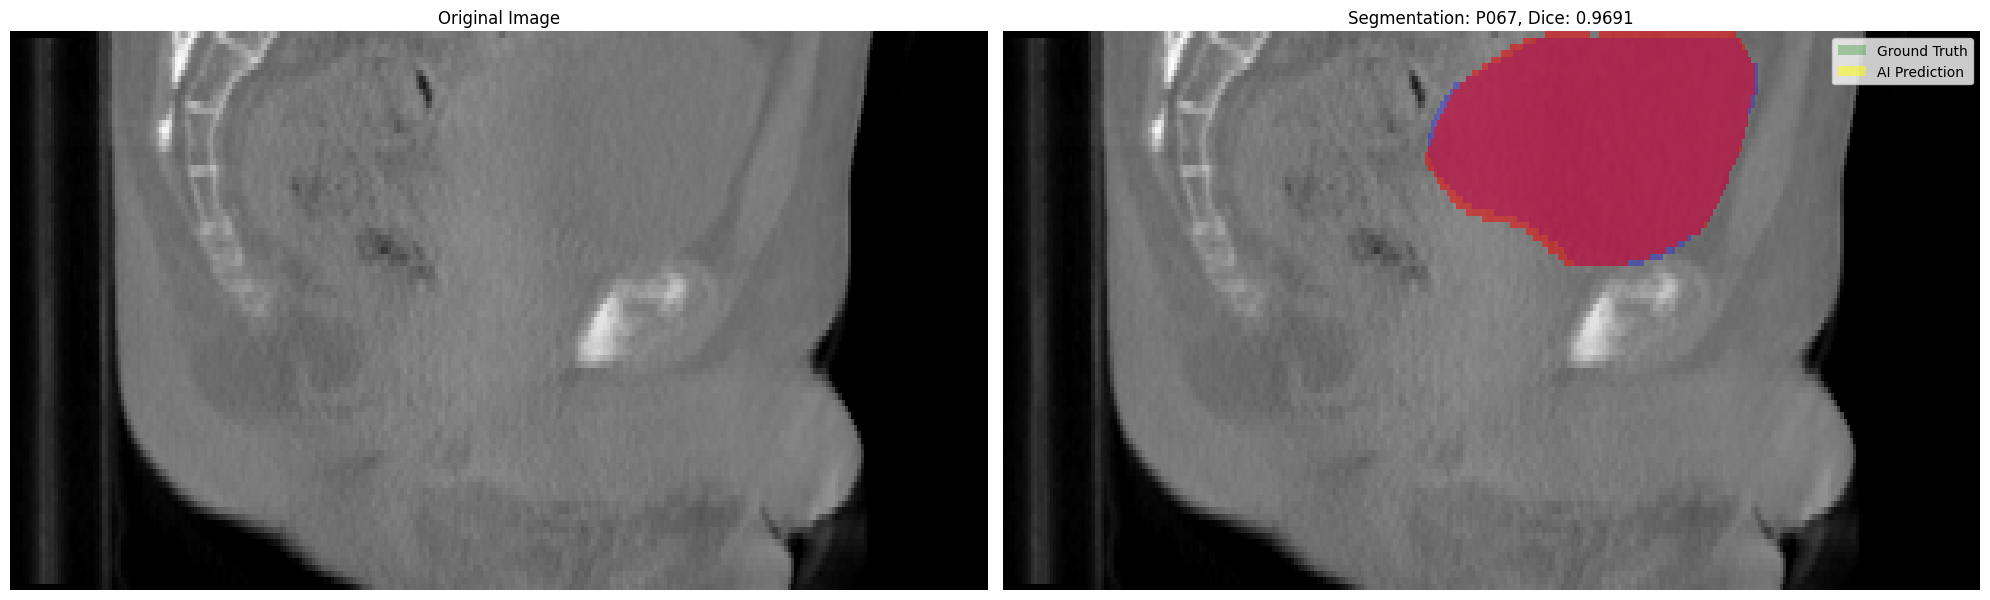

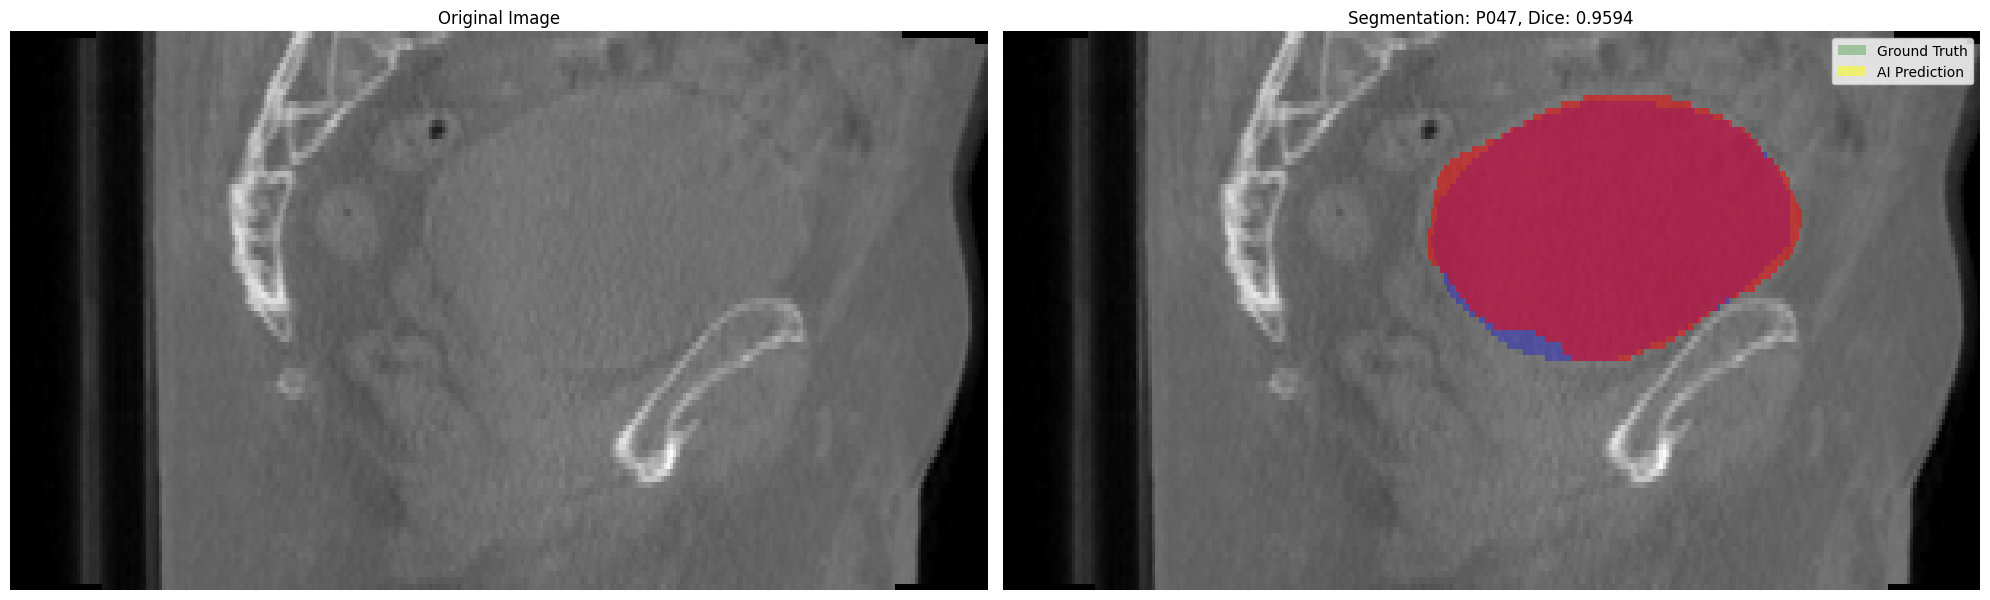

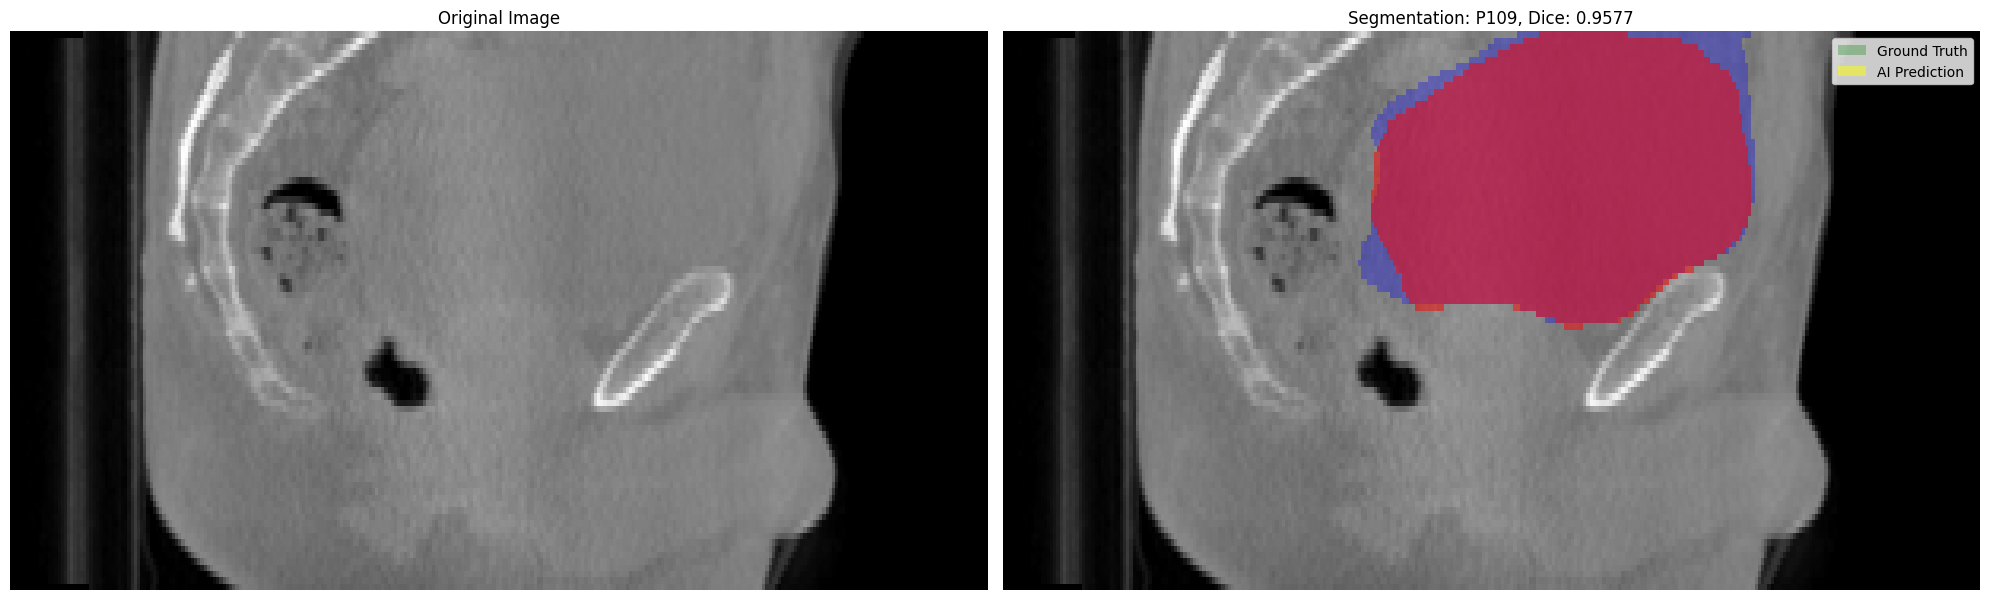

In [31]:
# also print the best-case segmentations for comparison
best_pats = val_results.groupby('pat_id')['dice'].mean().nlargest(3).index
for pat_id in best_pats:
    pat_idx = val_df[val_df['pat_id'] == pat_id].index[0]
    pat_df = val_df.iloc[pat_idx]
    
    # Get image and mask dimensions
    img = pat_df['images']
    height, width = img.shape
    
    # Calculate cropping indices (remove 1/5 from each side, i.e., 20% of width)
    crop_width = int(width * 0.2)  # 1/5 of width
    crop_slice = slice(crop_width, width - crop_width)
    
    # Crop images and masks
    cropped_img = img[:, crop_slice]
    cropped_ground_truth = pat_df['masks'][:, crop_slice]
    cropped_pred_mask = val_masks_pred_binary[pat_idx].squeeze()[:, crop_slice]
    
    # Create 1x2 subplot grid
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Plot original cropped image
    sns.heatmap(cropped_img, ax=axes[0], cmap='gray', cbar=False)
    axes[0].set_title('Original Image')
    axes[0].set_aspect(2)
    axes[0].axis('off')
    
    # Plot overlaid masks
    sns.heatmap(cropped_img, ax=axes[1], cmap='gray', cbar=False)
    
    # Ground truth mask (blue, translucent)
    cmask_zeros = cropped_ground_truth == 0
    alpha = np.ones_like(cropped_ground_truth, dtype=float) * 0.3
    alpha[cmask_zeros] = 0.0
    blue_cmap = ListedColormap(['none', 'blue'])
    sns.heatmap(cropped_ground_truth, ax=axes[1], cmap=blue_cmap, alpha=alpha, cbar=False)
    
    # AI-generated mask (red, translucent)
    vmask_zeros = cropped_pred_mask == 0
    alpha = np.ones_like(cropped_pred_mask, dtype=float) * 0.5
    alpha[vmask_zeros] = 0.0
    red_cmap = ListedColormap(['none', 'red'])
    sns.heatmap(cropped_pred_mask, ax=axes[1], cmap=red_cmap, alpha=alpha, cbar=False)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.3, label='Ground Truth'),
        Patch(facecolor='yellow', alpha=0.5, label='AI Prediction')
    ]
    axes[1].legend(handles=legend_elements, loc='upper right')
    
    axes[1].set_aspect(2)
    axes[1].axis('off')
    axes[1].set_title(f'Segmentation: {pat_id}, Dice: {val_results[val_results["pat_id"] == pat_id]["dice"].mean():.4f}')
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Save to subfolder
    plt.savefig(f'images/bladder/best_val_case_{pat_id}.png', bbox_inches='tight')
    plt.show()
    plt.close()

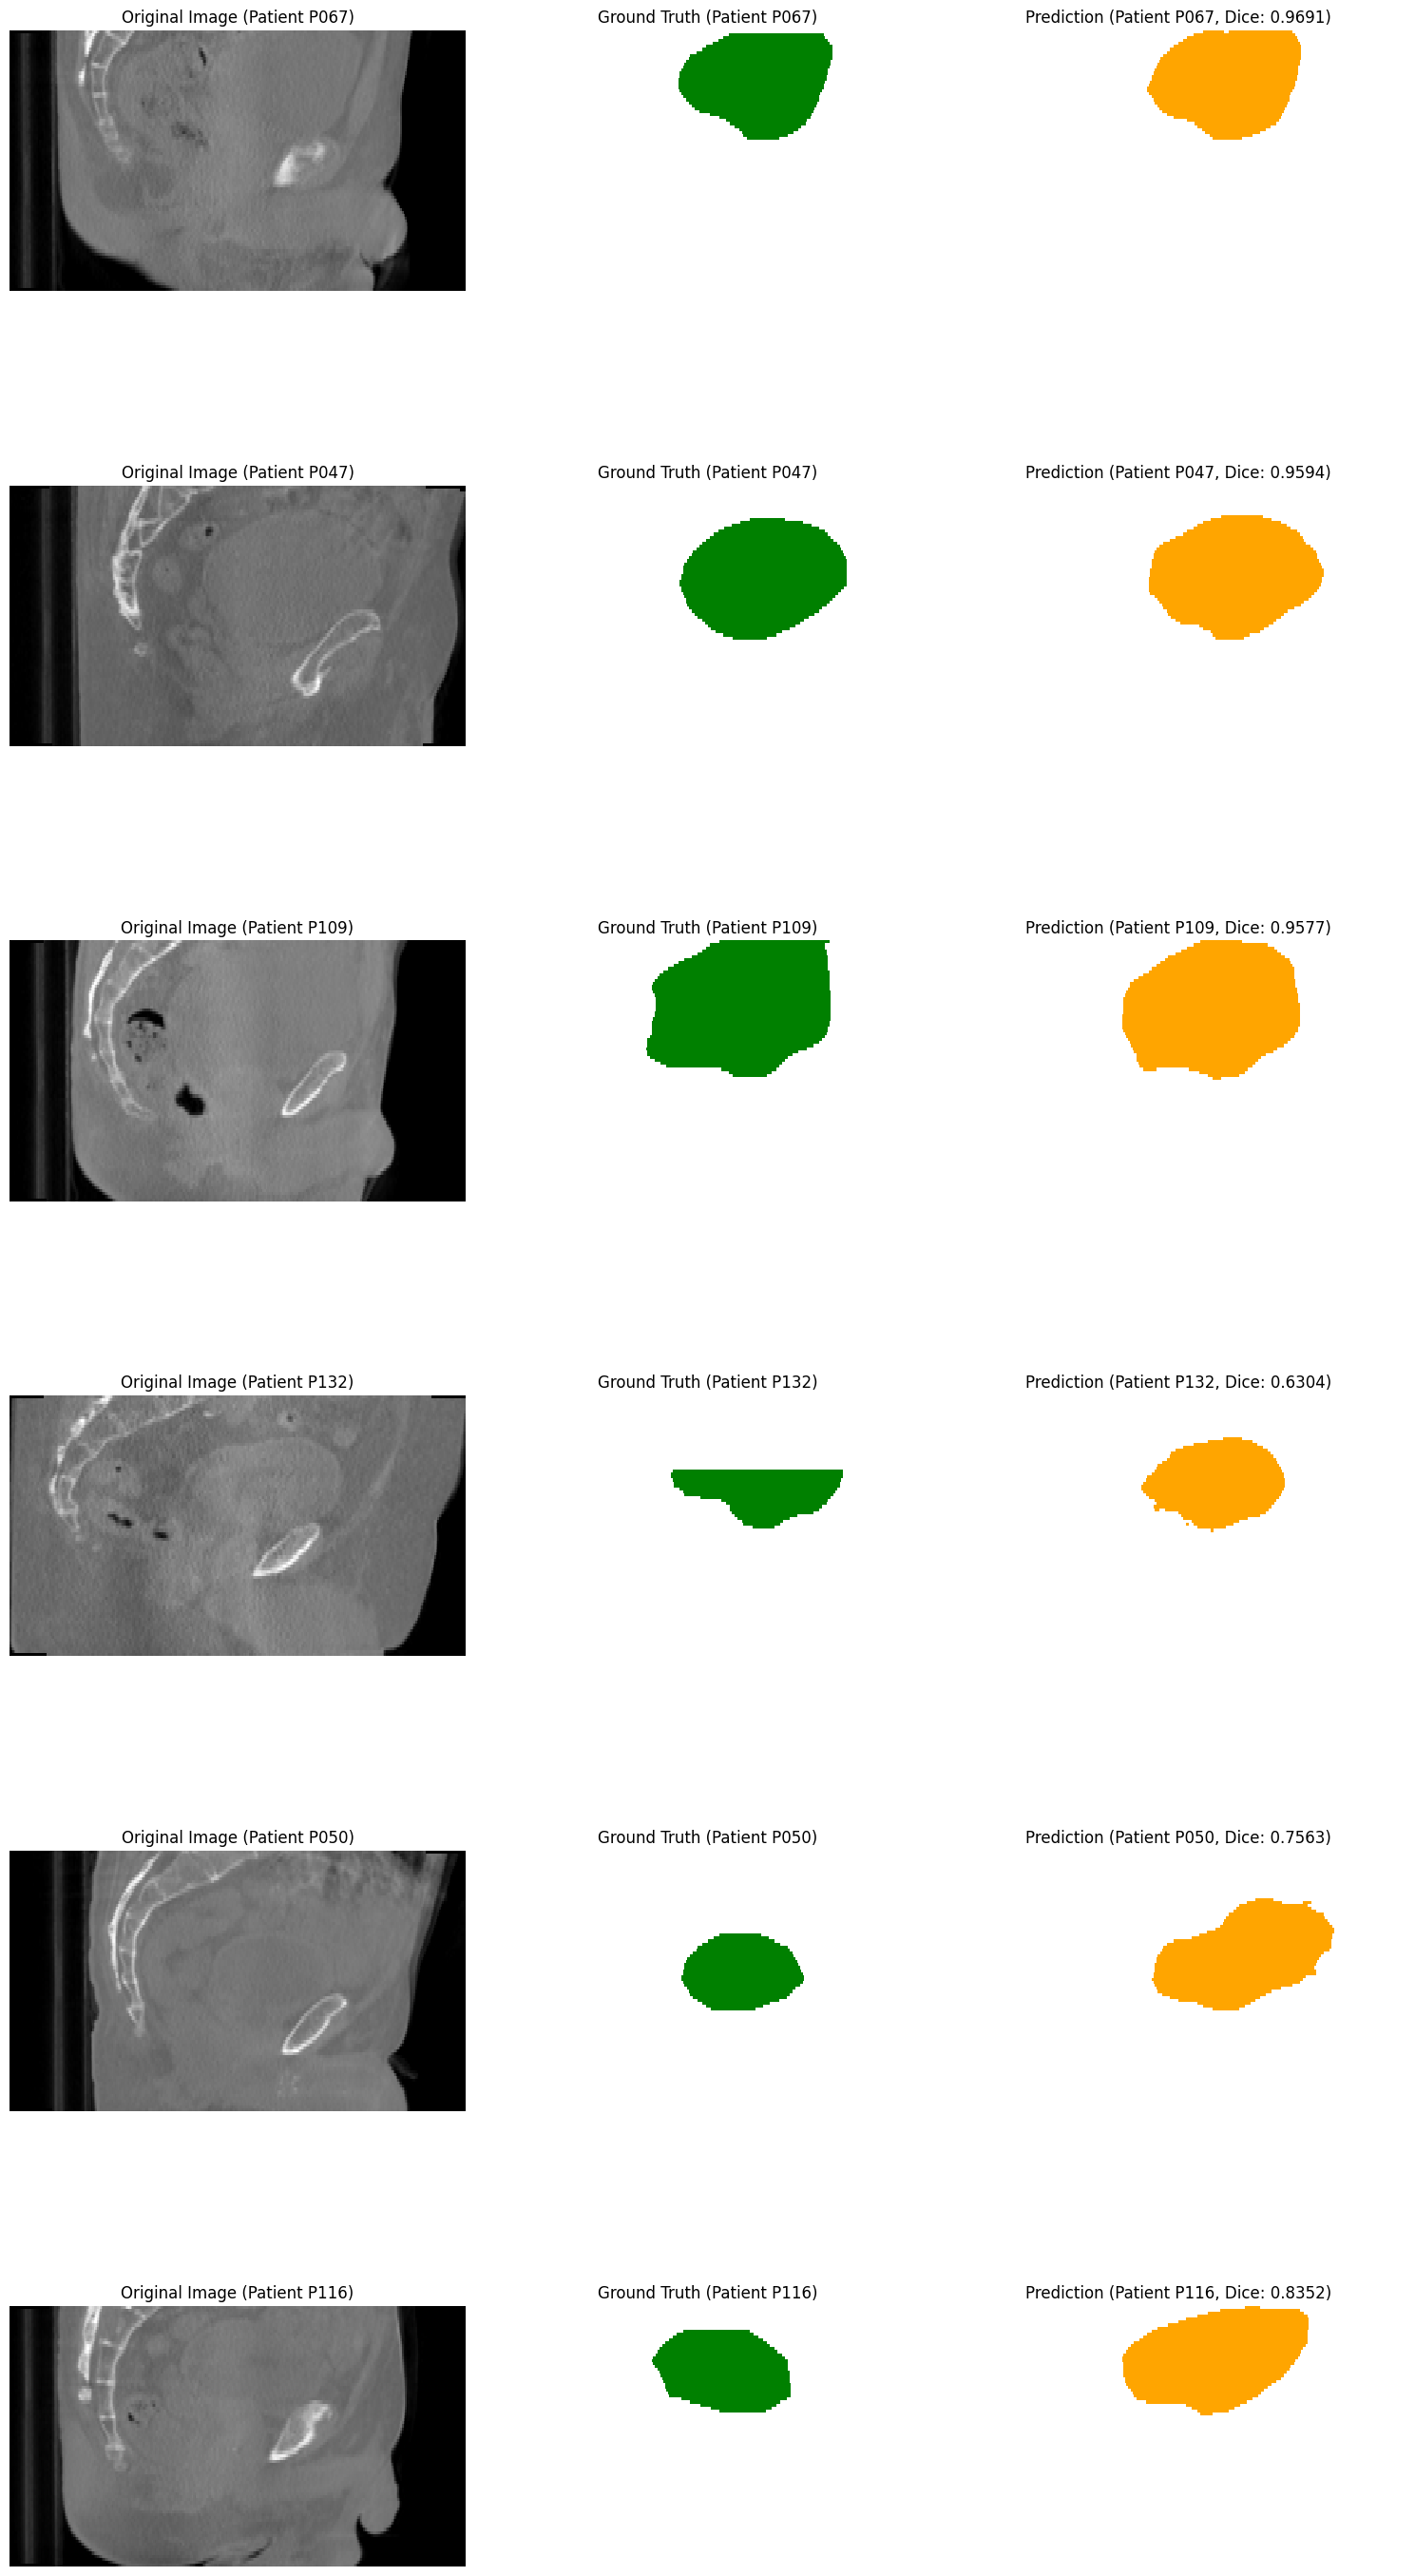

In [34]:
# Select best and worst 3 patients based on mean Dice score
best_pats = val_results.groupby('pat_id')['dice'].mean().nlargest(3).index
worst_pats = val_results.groupby('pat_id')['dice'].mean().nsmallest(3).index
selected_pats = list(best_pats) + list(worst_pats)

# Create 6x3 grid (6 patients: 3 best, 3 worst; each with 3 images)
fig, axes = plt.subplots(6, 3, figsize=(15, 30))  # 6 rows, 3 columns

for i, pat_id in enumerate(selected_pats):
    pat_idx = val_df[val_df['pat_id'] == pat_id].index[0]
    pat_df = val_df.iloc[pat_idx]
    
    # Get image and mask dimensions
    img = pat_df['images']
    height, width = img.shape
    
    # Calculate cropping indices (remove 1/5 from each side, i.e., 20% of width)
    crop_width = int(width * 0.2)  # 1/5 of width
    crop_slice = slice(crop_width, width - crop_width)
    
    # Crop images and masks
    cropped_img = img[:, crop_slice]
    cropped_ground_truth = pat_df['masks'][:, crop_slice]
    cropped_pred_mask = val_masks_pred_binary[pat_idx].squeeze()[:, crop_slice]
    
    # Plot original cropped image
    sns.heatmap(cropped_img, ax=axes[i, 0], cmap='gray', cbar=False)
    axes[i, 0].set_title(f'Original Image (Patient {pat_id})')
    axes[i, 0].set_aspect(2)
    axes[i, 0].axis('off')
    
    # Save original image
    fig_single = plt.figure(figsize=(5, 10))
    sns.heatmap(cropped_img, cmap='gray', cbar=False)
    plt.axis('off')
    plt.savefig(f'images/bladder/pat_{pat_id}_original.png', bbox_inches='tight', dpi=300)
    plt.close(fig_single)
    
    # Plot ground truth mask
    sns.heatmap(cropped_ground_truth, ax=axes[i, 1], cmap=ListedColormap(['none', 'green']), cbar=False)
    axes[i, 1].set_title(f'Ground Truth (Patient {pat_id})')
    axes[i, 1].set_aspect(2)
    axes[i, 1].axis('off')
    
    # Save ground truth image
    fig_single = plt.figure(figsize=(5, 10))
    sns.heatmap(cropped_ground_truth, cmap=ListedColormap(['none', 'green']), cbar=False)
    plt.axis('off')
    plt.savefig(f'images/bladder/pat_{pat_id}_ground_truth.png', bbox_inches='tight', dpi=300)
    plt.close(fig_single)
    
    # Plot predicted mask
    sns.heatmap(cropped_pred_mask, ax=axes[i, 2], cmap=ListedColormap(['none', 'orange']), cbar=False)
    axes[i, 2].set_title(f'Prediction (Patient {pat_id}, Dice: {val_results[val_results["pat_id"] == pat_id]["dice"].mean():.4f})')
    axes[i, 2].set_aspect(2)
    axes[i, 2].axis('off')
    
    # Save predicted mask
    fig_single = plt.figure(figsize=(5, 10))
    sns.heatmap(cropped_pred_mask, cmap=ListedColormap(['none', 'orange']), cbar=False)
    plt.axis('off')
    plt.savefig(f'images/bladder/pat_{pat_id}_predicted.png', bbox_inches='tight', dpi=300)
    plt.close(fig_single)

# Add legend to the grid
# legend_elements = [
    # Patch(facecolor='green', label='Ground Truth'),
    # Patch(facecolor='orange', label='AI Prediction')
# ]
# fig.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))

# Adjust layout
plt.tight_layout()

# Save the full 6x3 grid
plt.savefig('images/bladder/segmentation_grid_6x3.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()